In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [3]:
#split data into training and test sets
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

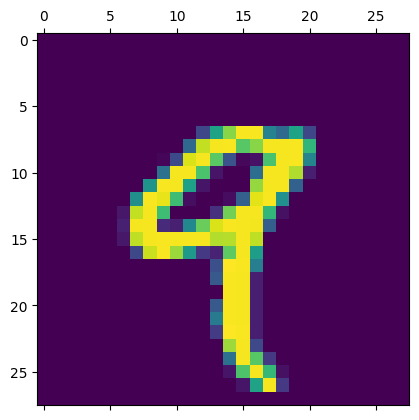

In [4]:
#showing a sample out of the dataset
plt.matshow(X_train[4])

In [5]:
X_train.shape

(60000, 28, 28)

In [6]:
X_train[0].shape

(28, 28)

In [12]:
#rescaling the images values to give better accuracy
X_train = X_train/255
X_test = X_test/255

In [13]:
#reshapping of X_train and X_test (flattening)
X_train_reshapped = X_train.reshape(len(X_train), 28*28)
X_test_reshapped = X_test.reshape(len(X_test), 28*28)

In [14]:
X_train_reshapped.shape


(60000, 784)

In [15]:
X_test_reshapped.shape

(10000, 784)

In [18]:
model = keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,),activation='sigmoid')
])
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'] )

model.fit(X_train_reshapped,y_train,epochs = 10)

d:\Projects\Tensorflow valut\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 762us/step - accuracy: 0.8781 - loss: 0.4675
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - accuracy: 0.9153 - loss: 0.3038
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step - accuracy: 0.9207 - loss: 0.2831
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 770us/step - accuracy: 0.9238 - loss: 0.2727
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 800us/step - accuracy: 0.9261 - loss: 0.2668
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 774us/step - accuracy: 0.9273 - loss: 0.2618
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step - accuracy: 0.9290 - loss: 0.2581
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step - accuracy: 0.9295 - loss: 0.2556
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.9298 - loss: 0.2529
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - accuracy: 0.9313 - loss: 0.2508


In [19]:
model.evaluate(X_test_reshapped, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step - accuracy: 0.9258 - loss: 0.2630


[0.26299676299095154, 0.9258000254631042]

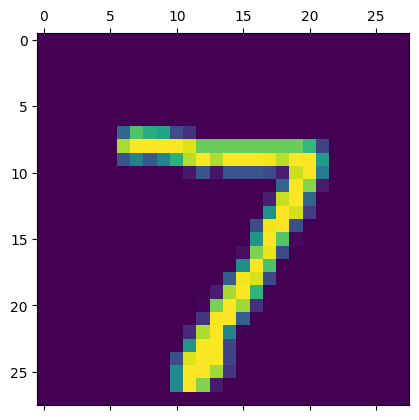

In [21]:
plt.matshow(X_test[0])

In [23]:
predicted_values = model.predict(X_test_reshapped)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step


In [24]:
predicted_values[0]

array([3.2593540e-03, 1.3389517e-08, 1.9114610e-02, 9.7048068e-01,
       3.0420423e-03, 1.5613902e-01, 2.8491037e-08, 9.9985963e-01,
       1.2087224e-01, 6.5722489e-01], dtype=float32)

In [25]:
#numpy to convert sigmoid output to the final output
np.argmax(predicted_values[0])

np.int64(7)

In [26]:
predicted_labels = [np.argmax(i) for i in predicted_values]

In [28]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=predicted_labels)

Text(95.72222222222221, 0.5, 'Truth')

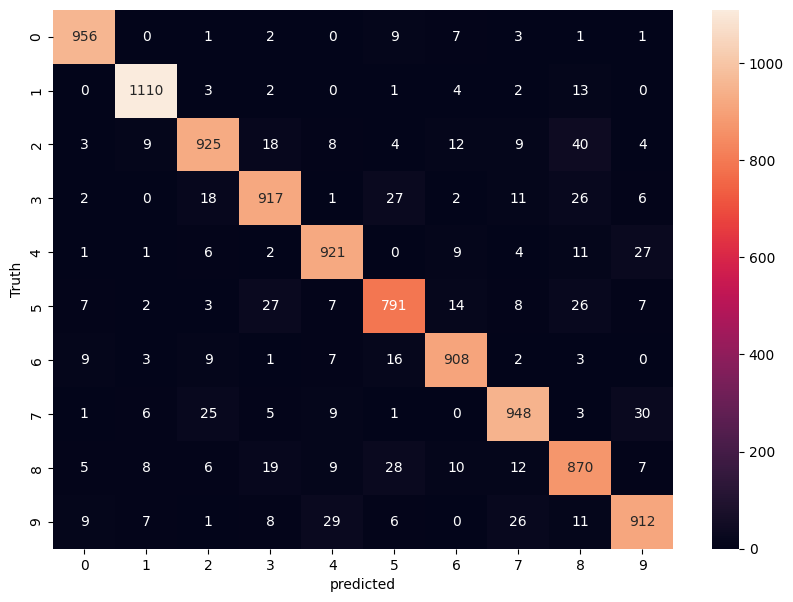

In [30]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel('predicted')
plt.ylabel('Truth')